In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

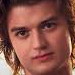

People/IMG_2.png saved


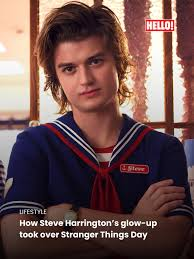

In [2]:
import cv2
import os
from google.colab.patches import cv2_imshow

# -------------------------
# Load image
# -------------------------
img = cv2.imread('steve.jpg')

if img is None:
    raise FileNotFoundError("Image not found")

# -------------------------
# Preprocess
# -------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.equalizeHist(gray)

# -------------------------
# Load cascade
# -------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

if face_cascade.empty():
    raise IOError("Cascade not loaded")

# -------------------------
# Detect faces
# -------------------------
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# -------------------------
# Save function
# -------------------------
def save(frame, folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    name_img = len(os.listdir(folder_name)) + 1
    path = f"{folder_name}/IMG_{name_img}.png"

    cv2.imwrite(path, frame)
    print(path, "saved")

# -------------------------
# Process faces
# -------------------------
for i, (x, y, w, h) in enumerate(faces):
    face = img[y:y+h, x:x+w]

    # Show face
    cv2_imshow(face)

    # Auto-save (since no keyboard input in Colab)
    save(face, 'People')

# Show full image
cv2_imshow(img)